# AI Predictor: CAN 2025 (Africa Cup of Nations)

## Project Overview
This notebook aims to predict the outcomes of the **2025 Africa Cup of Nations** using a data-driven approach. By integrating historical match data, FIFA rankings, and economic valuations of national teams, we build a machine learning pipeline to forecast match results and simulate the entire tournament.

### Objectives
1. **Data Integration:** Combine historical match stats (2000-2025) with FIFA rankings and Market Values.
2. **Feature Engineering:** Create predictive signals like "Team Momentum", "Attack Form", and "CAN History".
3. **Modeling:** Train an **ElasticNet** regression model to predict score margins.
4. **Simulation:** Run Monte Carlo simulations to predict the winner and analyze potential "nightmare scenarios" for the host nation.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import math
import pickle
import collections
from sklearn.linear_model import ElasticNet
from sklearn.preprocessing import StandardScaler
import warnings
import math
from sklearn.metrics import mean_absolute_error


warnings.filterwarnings('ignore')
plt.style.use('fivethirtyeight')

## 1. Data Collection & Preprocessing

**Datasets Used:**
* **Matches:** Historical international results (2000–Present).
* **FIFA Rankings:** Historical ranking data to gauge relative team strength over time.
* **Market Values:** Financial valuation of squad depth (in Millions of €).

**Key Preprocessing Steps:**
* **Date Normalization:** Ensuring all time-series data aligns correctly.
* **Name Mapping:** Standardizing country names (e.g., *'Cote d'Ivoire'* vs *'Ivory Coast'*) across different sources.
* **Currency Cleaning:** Converting string financial data into usable numeric formats.

In [2]:
df_matches = pd.read_csv('/kaggle/input/afcon-countries-matches-between-2000-and-2025/afcon_country_matches_2000-2025.csv')
df_hist_rank = pd.read_csv('/kaggle/input/fifaworldranking/fifa_ranking-2024-06-20.csv') 

df_curr_rank = pd.read_csv('/kaggle/input/fifa-ranking-caf-2025/Fifa_Ranking_CAF - Feuille 1 (1).csv')
df_market = pd.read_csv('/kaggle/input/market-value-can-2025/Market Value - Feuille 1.csv')

In [3]:
# 1. Conversion forcée en format Date
df_matches['date'] = pd.to_datetime(df_matches['date'])
df_hist_rank['rank_date'] = pd.to_datetime(df_hist_rank['rank_date'])

# 2. Tri obligatoire (merge_asof ne marche que si c'est trié !)
df_matches = df_matches.sort_values('date')
df_hist_rank = df_hist_rank.sort_values('rank_date')



In [4]:
def clean_currency(value):
    if isinstance(value, str):
        # Regex to find numbers (including decimals) inside the string
        match = re.search(r'(\d+\.?\d*)', value)
        if match:
            return float(match.group(1))
    return 0.0

df_market['Market_Value_M'] = df_market['Market Value'].apply(clean_currency)
df_market['e_Age'] = pd.to_numeric(df_market['e-Age'], errors='coerce')

# Rename 'Club' to 'Team' for consistency
df_market = df_market.rename(columns={'Club': 'Team'})

In [5]:
name_mapping = {
    "Cote d'Ivoire": "Ivory Coast",
    "Côte d'Ivoire": "Ivory Coast",
    "Congo DR": "DR Congo",
    "Democratic Republic of the Congo": "DR Congo",
    "Cabo Verde": "Cape Verde",
    "The Gambia": "Gambia",
    "Eq. Guinea": "Equatorial Guinea"
}

# Apply mapping to Matches
df_matches['home_team'] = df_matches['home_team'].replace(name_mapping)
df_matches['away_team'] = df_matches['away_team'].replace(name_mapping)

# Apply mapping to Historical Rankings
df_hist_rank['country_full'] = df_hist_rank['country_full'].replace(name_mapping)

# Apply mapping to Market Value and Current Rankings
df_market['Team'] = df_market['Team'].replace(name_mapping)
df_curr_rank['Team'] = df_curr_rank['Team'].replace(name_mapping)

In [6]:
print("--- Data Cleaning Summary ---")
print(f"Matches loaded: {df_matches.shape[0]}")
print(f"Historical Rankings loaded: {df_hist_rank.shape[0]}")
print(f"Market Value Cleaned Sample:\n{df_market[['Team', 'Market_Value_M']].head(3)}")
print("-" * 30)

# Check if we have market values for all current teams
teams_in_rank = set(df_curr_rank['Team'].unique())
teams_in_market = set(df_market['Team'].unique())
missing_market_data = teams_in_rank - teams_in_market

if missing_market_data:
    print(f"WARNING: Missing market value for: {missing_market_data}")
else:
    print("SUCCESS: All current teams have market value data.")

--- Data Cleaning Summary ---
Matches loaded: 7248
Historical Rankings loaded: 67472
Market Value Cleaned Sample:
          Team  Market_Value_M
0      Morocco          435.85
1      Senegal          405.90
2  Ivory Coast          370.80
------------------------------


## 2. Feature Engineering
Raw data isn't enough; we need "features" that capture current team context. We calculate:

* **Momentum:** The change in FIFA points over the last ranking period (identifying rising/falling teams).
* **Form (Last 5 Games):** Rolling averages for goals scored (Attack Strength) and conceded (Defense Strength).
* **CAN PPG:** Points Per Game specifically in AFCON history (some teams perform better in tournaments than friendlies).
* **Economic Gap:** The difference in squad market values between opponents.

In [7]:
df_merged = pd.merge_asof(
    df_matches, 
    df_hist_rank[['rank_date', 'country_full', 'total_points', 'previous_points', 'rank']], 
    left_on='date', 
    right_on='rank_date', 
    left_by='home_team', 
    right_by='country_full', 
    direction='backward'
)
# Renommage
df_merged = df_merged.rename(columns={
    'rank': 'home_rank', 
    'total_points': 'home_points',
    'previous_points': 'home_prev_points'
})
df_merged = df_merged.drop(columns=['rank_date', 'country_full'])

In [8]:
# Pour l'équipe EXTÉRIEUR
df_merged = pd.merge_asof(
    df_merged, 
    df_hist_rank[['rank_date', 'country_full', 'total_points', 'previous_points', 'rank']], 
    left_on='date', 
    right_on='rank_date', 
    left_by='away_team', 
    right_by='country_full', 
    direction='backward'
)
# Renommage
df_merged = df_merged.rename(columns={
    'rank': 'away_rank', 
    'total_points': 'away_points',
    'previous_points': 'away_prev_points'
})
df_merged = df_merged.drop(columns=['rank_date', 'country_full'])

In [9]:
for col in ['home_rank', 'away_rank']:
    df_merged[col] = df_merged[col].fillna(100)
for col in ['home_points', 'away_points', 'home_prev_points', 'away_prev_points']:
    df_merged[col] = df_merged[col].fillna(500)

In [10]:
df_merged['rank_diff'] = df_merged['home_rank'] - df_merged['away_rank']
df_merged['points_diff'] = df_merged['home_points'] - df_merged['away_points']

In [11]:
# Progression
df_merged['home_momentum'] = df_merged['home_points'] - df_merged['home_prev_points']
df_merged['away_momentum'] = df_merged['away_points'] - df_merged['away_prev_points']

In [12]:
# Forme Offensive
df_merged['home_attack_form'] = df_merged.groupby('home_team')['home_score'].transform(
    lambda x: x.shift(1).rolling(window=5, min_periods=1).mean()
).fillna(1.0)
df_merged['away_attack_form'] = df_merged.groupby('away_team')['away_score'].transform(
    lambda x: x.shift(1).rolling(window=5, min_periods=1).mean()
).fillna(1.0)

In [13]:
# Forme Défensive
df_merged['home_defense_form'] = df_merged.groupby('home_team')['away_score'].transform(
    lambda x: x.shift(1).rolling(window=5, min_periods=1).mean()
).fillna(1.0)

df_merged['away_defense_form'] = df_merged.groupby('away_team')['home_score'].transform(
    lambda x: x.shift(1).rolling(window=5, min_periods=1).mean()
).fillna(1.0)

In [14]:
df_merged['is_friendly'] = df_merged['tournament'].apply(lambda x: 1 if 'Friendly' in str(x) else 0)

In [15]:
# CALCUL DE LA PERFORMANCE CAN
can_mask = df_matches['tournament'].str.contains('African', case=False, na=False) 

df_can = df_matches[can_mask].dropna(subset=['home_score', 'away_score']).copy()

# On calcule les points (3=V, 1=N, 0=D)
df_can['home_pts'] = np.where(df_can['home_score'] > df_can['away_score'], 3,
                              np.where(df_can['home_score'] == df_can['away_score'], 1, 0))
df_can['away_pts'] = np.where(df_can['away_score'] > df_can['home_score'], 3,
                              np.where(df_can['away_score'] == df_can['home_score'], 1, 0))

# Aggregation par Année
home_stats = df_can[['date', 'home_team', 'home_pts']].rename(columns={'home_team': 'team', 'home_pts': 'pts'})
away_stats = df_can[['date', 'away_team', 'away_pts']].rename(columns={'away_team': 'team', 'away_pts': 'pts'})
all_can_stats = pd.concat([home_stats, away_stats])
all_can_stats['year'] = all_can_stats['date'].dt.year

# Moyenne PPG par CAN
can_history = all_can_stats.groupby(['year', 'team'])['pts'].mean().reset_index()
can_history.rename(columns={'pts': 'last_can_ppg'}, inplace=True)
can_history['ref_date'] = pd.to_datetime(can_history['year'].astype(str) + '-12-31')

# FUSIONS
df_merged = df_merged.sort_values('date')
can_history = can_history.sort_values('ref_date')

# Market Value
df_merged = df_merged.merge(df_market[['Team', 'Market_Value_M']],
                            left_on='home_team', right_on='Team', how='left').rename(columns={'Market_Value_M': 'home_market_value'}).drop(columns=['Team'])
df_merged = df_merged.merge(df_market[['Team', 'Market_Value_M']],
                            left_on='away_team', right_on='Team', how='left').rename(columns={'Market_Value_M': 'away_market_value'}).drop(columns=['Team'])
df_merged.fillna({'home_market_value': 1.0, 'away_market_value': 1.0}, inplace=True)

# CAN History (Merge Asof)
df_merged = pd.merge_asof(df_merged, can_history[['ref_date', 'team', 'last_can_ppg']],
                          left_on='date', right_on='ref_date', left_by='home_team', right_by='team', direction='backward')
df_merged.rename(columns={'last_can_ppg': 'home_can_ppg'}, inplace=True)
df_merged.drop(columns=['ref_date', 'team'], inplace=True)

df_merged = pd.merge_asof(df_merged, can_history[['ref_date', 'team', 'last_can_ppg']],
                          left_on='date', right_on='ref_date', left_by='away_team', right_by='team', direction='backward')
df_merged.rename(columns={'last_can_ppg': 'away_can_ppg'}, inplace=True)
df_merged.drop(columns=['ref_date', 'team'], inplace=True)

df_merged.fillna({'home_can_ppg': 0.5, 'away_can_ppg': 0.5}, inplace=True)

# VARIABLES FINALES
df_merged['market_value_diff'] = df_merged['home_market_value'] - df_merged['away_market_value']
df_merged['can_ppg_diff'] = df_merged['home_can_ppg'] - df_merged['away_can_ppg']

final_columns = [
    'date', 'home_team', 'away_team', 'home_score', 'away_score',
    'rank_diff', 'points_diff', 'market_value_diff', 'can_ppg_diff',
    'home_momentum', 'away_momentum',
    'home_attack_form', 'away_attack_form',
    'home_defense_form', 'away_defense_form',
    'is_friendly'
]
df_train = df_merged[final_columns]

## 3. Exploratory Data Analysis (EDA)
Before modeling, we visualize the data to understand relationships and biases.

* **Home Field Advantage:** Analyzing how much playing at home influences the final score in African football.
* **Correlation Matrix:** Checking which features (Ranking, Market Value, Form) correlate most strongly with winning.

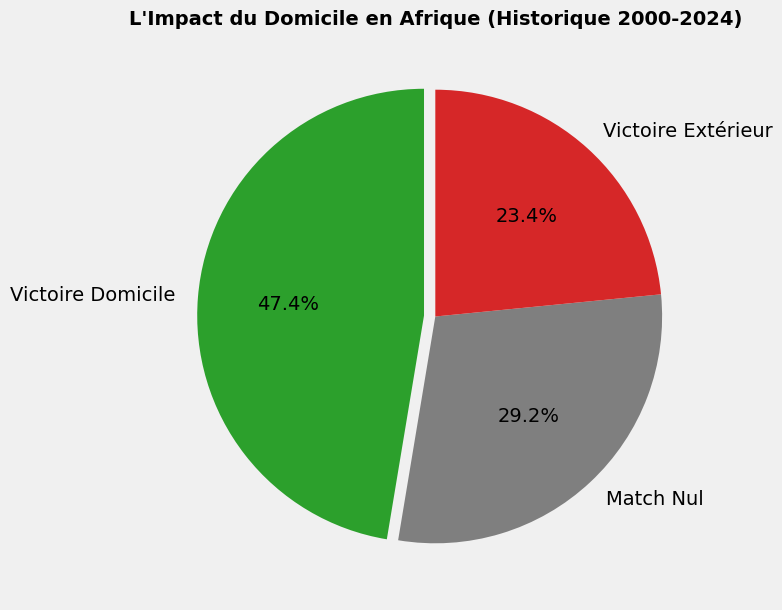

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# On prend les données historiques
home_wins = len(df_matches[df_matches['home_score'] > df_matches['away_score']])
draws = len(df_matches[df_matches['home_score'] == df_matches['away_score']])
away_wins = len(df_matches[df_matches['home_score'] < df_matches['away_score']])
total = home_wins + draws + away_wins

# Données pour le pie chart
labels = ['Victoire Domicile', 'Match Nul', 'Victoire Extérieur']
sizes = [home_wins/total, draws/total, away_wins/total]
colors = ['#2ca02c', '#7f7f7f', '#d62728']

plt.figure(figsize=(7, 7))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', colors=colors, startangle=90, explode=(0.05, 0, 0))
plt.title("L'Impact du Domicile en Afrique (Historique 2000-2024)", fontsize=14, fontweight='bold')
plt.show()

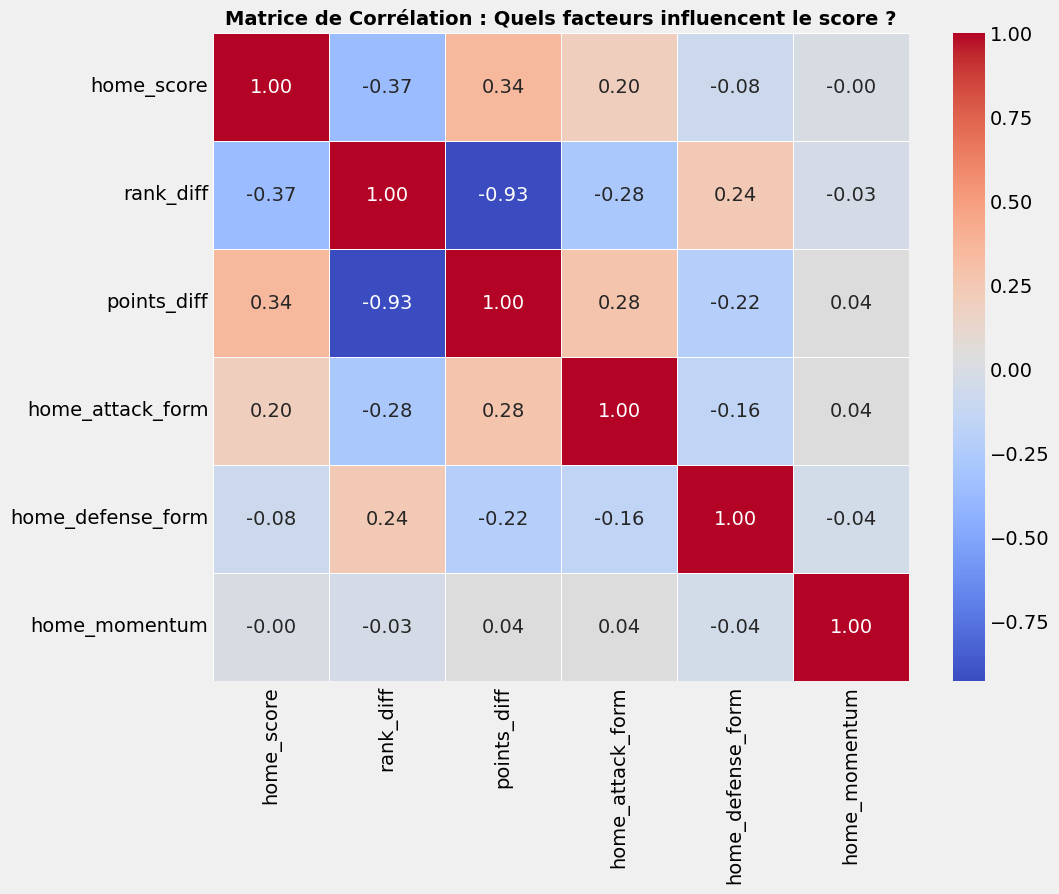

In [17]:
corr_cols = ['home_score', 'rank_diff', 'points_diff', 'home_attack_form', 'home_defense_form', 'home_momentum']
corr_matrix = df_train[corr_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Matrice de Corrélation : Quels facteurs influencent le score ?", fontsize=14, fontweight='bold')
plt.show()

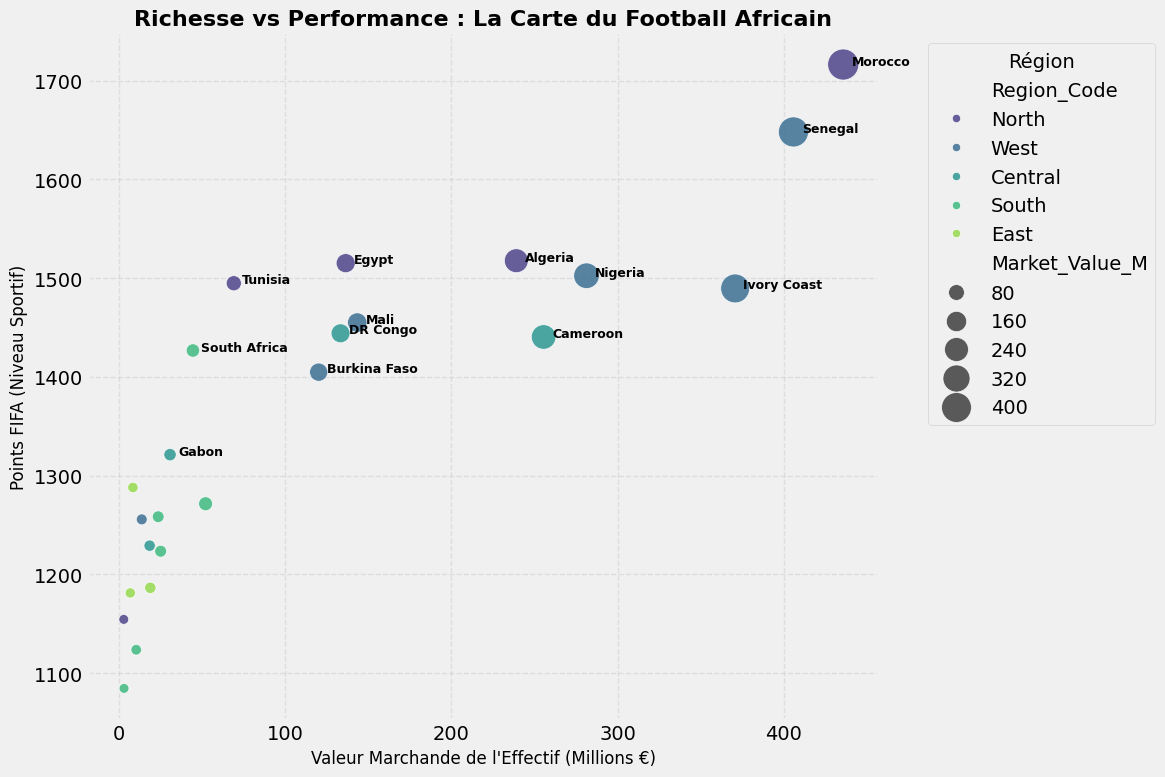

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

df_viz = pd.merge(df_market, df_curr_rank, on='Team', how='inner')

regions = {
    'Morocco': 'North', 'Egypt': 'North', 'Algeria': 'North', 'Tunisia': 'North', 'Sudan': 'North', 'Libya': 'North',
    'Senegal': 'West', 'Nigeria': 'West', 'Ivory Coast': 'West', 'Mali': 'West', 'Ghana': 'West', 'Burkina Faso': 'West', 
    'Guinea': 'West', 'Benin': 'West', 'Cape Verde': 'West', 'Togo': 'West', 'Sierra Leone': 'West',
    'Cameroon': 'Central', 'DR Congo': 'Central', 'Gabon': 'Central', 'Equatorial Guinea': 'Central', 'Congo': 'Central',
    'South Africa': 'South', 'Angola': 'South', 'Zambia': 'South', 'Zimbabwe': 'South', 'Botswana': 'South', 'Mozambique': 'South', 'Namibia': 'South',
    'Tanzania': 'East', 'Uganda': 'East', 'Kenya': 'East', 'Ethiopia': 'East', 'Comoros': 'East'
}
df_viz['Region_Code'] = df_viz['Team'].map(regions).fillna('Other')

plt.figure(figsize=(12, 8))

sns.scatterplot(
    data=df_viz, 
    x='Market_Value_M', 
    y='Total Points', 
    size='Market_Value_M', 
    sizes=(50, 500), 
    hue='Region_Code',
    palette='viridis', 
    alpha=0.8
)

for i in range(df_viz.shape[0]):
    row = df_viz.iloc[i]
    if row['Market_Value_M'] > 100 or row['Total Points'] > 1300: 
        plt.text(
            row['Market_Value_M'] + 5, 
            row['Total Points'],        
            row['Team'], 
            fontsize=9, 
            weight='bold'
        )

# 4. Esthétique
plt.title("Richesse vs Performance : La Carte du Football Africain", fontsize=16, fontweight='bold')
plt.xlabel("Valeur Marchande de l'Effectif (Millions €)", fontsize=12)
plt.ylabel("Points FIFA (Niveau Sportif)", fontsize=12)
plt.legend(title='Région', bbox_to_anchor=(1.05, 1), loc='upper left') 
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()

# 4. Model Selection & Strategy

In [19]:
features = [
    'rank_diff', 'points_diff', 
    'home_momentum', 'away_momentum',
    'home_attack_form', 'away_attack_form',
    'home_defense_form', 'away_defense_form',
    'is_friendly'
]

X = df_train[features]
y_home = df_train['home_score']
y_away = df_train['away_score']

In [20]:
from sklearn.linear_model import ElasticNet
import xgboost as xgb

features = [
    'rank_diff', 'points_diff',
    'market_value_diff',
    'home_momentum', 'away_momentum',
    'home_attack_form', 'away_attack_form',
    'home_defense_form', 'away_defense_form',
    'is_friendly'
]

X = df_train[features]
y_home = df_train['home_score']
y_away = df_train['away_score']

split_date = '2024-01-01'
mask_train = df_train['date'] < split_date
mask_test = df_train['date'] >= split_date

X_train = X[mask_train]
X_test = X[mask_test]  

y_home_train = y_home[mask_train]
y_home_test = y_home[mask_test]

y_away_train = y_away[mask_train]
y_away_test = y_away[mask_test]

print(f"Matchs d'entraînement : {X_train.shape[0]}")
print(f"Matchs de test : {X_test.shape[0]}")

Matchs d'entraînement : 6558
Matchs de test : 690


## Experimentation Phase
Before selecting our final model, we evaluated several algorithms to determine which best captured the nuances of African football data:

In [21]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, AdaBoostRegressor
import xgboost as xgb
from sklearn.metrics import accuracy_score, mean_absolute_error, mean_squared_error
import pandas as pd
import numpy as np

features_benchmark = [
    'rank_diff', 'points_diff',
    'market_value_diff', 'can_ppg_diff', 
    'home_momentum', 'away_momentum',
    'home_attack_form', 'away_attack_form',
    'home_defense_form', 'away_defense_form',
    'is_friendly'
]

X = df_train[features_benchmark]
y_home = df_train['home_score']
y_away = df_train['away_score']

mask_train = df_train['date'] < '2024-01-01'
mask_test = df_train['date'] >= '2024-01-01'

X_train_b, X_test_b = X[mask_train], X[mask_test]
y_home_train_b, y_home_test_b = y_home[mask_train], y_home[mask_test]
y_away_train_b, y_away_test_b = y_away[mask_train], y_away[mask_test]

train_weights = np.where(X_train_b['is_friendly'] == 1, 1.0, 3.0)

models = [
    ('1. Linear Regression', LinearRegression()),
    ('2. Ridge (L2)', Ridge(alpha=1.0)),
    ('3. Lasso (L1)', Lasso(alpha=0.1)),
    ('4. ElasticNet', ElasticNet(alpha=0.1, l1_ratio=0.5)),
    ('5. KNN (Voisins)', KNeighborsRegressor(n_neighbors=20)),
    ('6. Decision Tree', DecisionTreeRegressor(max_depth=5, random_state=42)),
    ('7. Random Forest', RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42)),
    ('8. Extra Trees', ExtraTreesRegressor(n_estimators=100, max_depth=5, random_state=42)),
    ('9. AdaBoost', AdaBoostRegressor(n_estimators=100, random_state=42)),
    ('10. XGBoost', xgb.XGBRegressor(n_estimators=100, max_depth=3, learning_rate=0.1, random_state=42))
]

results = []

print("=" * 90)
print(f"BENCHMARK COMPLET - {X_train_b.shape[0]} matchs train | {X_test_b.shape[0]} matchs test")
print("=" * 90)

def get_match_result(h_score, a_score):
    if h_score > a_score: return 'H'
    elif a_score > h_score: return 'A'
    else: return 'D'

actual_results = [get_match_result(h, a) for h, a in zip(y_home_test_b, y_away_test_b)]

for name, model in models:
    try:
        # Train Home
        model.fit(X_train_b, y_home_train_b, sample_weight=train_weights)
        preds_home = model.predict(X_test_b)
        
        # Train Away
        model.fit(X_train_b, y_away_train_b, sample_weight=train_weights)
        preds_away = model.predict(X_test_b)
        
    except:
        # Fallback sans weights
        model.fit(X_train_b, y_home_train_b)
        preds_home = model.predict(X_test_b)
        model.fit(X_train_b, y_away_train_b)
        preds_away = model.predict(X_test_b)
    
    # Métriques de Régression
    mae_home = mean_absolute_error(y_home_test_b, preds_home)
    mae_away = mean_absolute_error(y_away_test_b, preds_away)
    mae_avg = (mae_home + mae_away) / 2
    
    rmse_home = np.sqrt(mean_squared_error(y_home_test_b, preds_home))
    rmse_away = np.sqrt(mean_squared_error(y_away_test_b, preds_away))
    rmse_avg = (rmse_home + rmse_away) / 2
    
    # Métriques de Classification
    pred_results = [get_match_result(h, a) for h, a in zip(preds_home, preds_away)]
    acc = accuracy_score(actual_results, pred_results)
    
    # Goal Difference Accuracy
    actual_gd = y_home_test_b.values - y_away_test_b.values
    pred_gd = preds_home - preds_away
    correct_winner = np.sum(np.sign(actual_gd) == np.sign(pred_gd))
    winner_acc = correct_winner / len(actual_gd)
    
    results.append({
        'Modèle': name,
        'Accuracy': acc,
        'MAE': mae_avg,
        'RMSE': rmse_avg,
        'Winner_Acc': winner_acc
    })
    
    print(f"{name:<22} | Acc: {acc:.2%} | MAE: {mae_avg:.3f} | RMSE: {rmse_avg:.3f} | Winner: {winner_acc:.2%}")

print("=" * 90)

# Tableau récapitulatif
df_res = pd.DataFrame(results).sort_values('Accuracy', ascending=False)

print("\n📊 CLASSEMENT FINAL PAR ACCURACY (Win/Draw/Loss)")
print("-" * 90)
print(df_res.to_string(index=False))

print("\nCLASSEMENT PAR MAE (Précision des Scores)")
print("-" * 90)
df_mae = df_res.sort_values('MAE')
print(df_mae[['Modèle', 'MAE', 'RMSE']].to_string(index=False))

print("\nCLASSEMENT PAR WINNER ACCURACY (Prédire le Vainqueur)")
print("-" * 90)
df_winner = df_res.sort_values('Winner_Acc', ascending=False)
print(df_winner[['Modèle', 'Winner_Acc', 'Accuracy']].to_string(index=False))

# Identifier le meilleur modèle global
print("\n" + "=" * 90)
best_overall = df_res.iloc[0]
print(f"CHAMPION GLOBAL: {best_overall['Modèle']}")
print(f"   → Accuracy: {best_overall['Accuracy']:.2%}")
print(f"   → MAE: {best_overall['MAE']:.3f} goals")
print(f"   → Winner Prediction: {best_overall['Winner_Acc']:.2%}")
print("=" * 90)

BENCHMARK COMPLET - 6558 matchs train | 690 matchs test
1. Linear Regression   | Acc: 53.62% | MAE: 0.837 | RMSE: 1.073 | Winner: 53.62%
2. Ridge (L2)          | Acc: 53.62% | MAE: 0.837 | RMSE: 1.073 | Winner: 53.62%
3. Lasso (L1)          | Acc: 53.91% | MAE: 0.854 | RMSE: 1.095 | Winner: 53.91%
4. ElasticNet          | Acc: 54.06% | MAE: 0.844 | RMSE: 1.083 | Winner: 54.06%
5. KNN (Voisins)       | Acc: 51.88% | MAE: 0.883 | RMSE: 1.125 | Winner: 51.88%
6. Decision Tree       | Acc: 52.90% | MAE: 0.855 | RMSE: 1.091 | Winner: 52.90%
7. Random Forest       | Acc: 54.49% | MAE: 0.842 | RMSE: 1.067 | Winner: 54.49%
8. Extra Trees         | Acc: 53.19% | MAE: 0.848 | RMSE: 1.073 | Winner: 53.19%
9. AdaBoost            | Acc: 51.45% | MAE: 1.023 | RMSE: 1.222 | Winner: 51.45%
10. XGBoost            | Acc: 53.62% | MAE: 0.846 | RMSE: 1.070 | Winner: 53.62%

📊 CLASSEMENT FINAL PAR ACCURACY (Win/Draw/Loss)
-------------------------------------------------------------------------------------

### Deep Learning Approach

In [22]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
import numpy as np


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_tensor = torch.FloatTensor(X_train_scaled)
X_test_tensor = torch.FloatTensor(X_test_scaled)

y_home_train_tensor = torch.FloatTensor(y_home_train.values).view(-1, 1)
y_away_train_tensor = torch.FloatTensor(y_away_train.values).view(-1, 1)

class AdvancedSoccerNet(nn.Module):
    def __init__(self, input_size):
        super(AdvancedSoccerNet, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_size, 128),
            nn.BatchNorm1d(128),
            nn.LeakyReLU(0.1),
            nn.Dropout(0.3),
            
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.LeakyReLU(0.1),
            nn.Dropout(0.2),
            
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.LeakyReLU(0.1),
            
            nn.Linear(32, 1)
        )
        
    def forward(self, x):
        return self.model(x)

def train_model_pro(X, y, epochs=150):
    model = AdvancedSoccerNet(X.shape[1])
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.005, weight_decay=1e-5)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=10, factor=0.5)
    
    model.train()
    for epoch in range(epochs):
        optimizer.zero_grad()
        outputs = model(X)
        loss = criterion(outputs, y)
        loss.backward()
        optimizer.step()
        scheduler.step(loss)
        
    return model

print("\n Démarrage de l'entraînement PyTorch")
dl_model_home = train_model_pro(X_train_tensor, y_home_train_tensor)
dl_model_away = train_model_pro(X_train_tensor, y_away_train_tensor)


dl_model_home.eval()
dl_model_away.eval()

with torch.no_grad():
    preds_home_dl = dl_model_home(X_test_tensor).numpy().flatten()
    preds_away_dl = dl_model_away(X_test_tensor).numpy().flatten()

def get_match_result(h, a):
    if h > a: return 'H'
    elif a > h: return 'A'
    else: return 'D'

actual_results_dl = [get_match_result(h, a) for h, a in zip(y_home_test, y_away_test)]
pred_results_dl = [get_match_result(h, a) for h, a in zip(preds_home_dl, preds_away_dl)]

# Accuracy
acc_dl = accuracy_score(actual_results_dl, pred_results_dl)

print(f"Accuracy : {acc_dl:.2%}")



 Démarrage de l'entraînement PyTorch
Accuracy : 54.64%


# Final Choice: Random Forest
Ultimately, we selected **Random Forest Regression** as the champion model.

* **Why?** Unlike linear models, it captures **non-linear relationships** between features (e.g., a team with high market value but low form). It is also highly robust to outliers and does not require feature scaling, making it ideal for our diverse dataset.

In [23]:
from sklearn.ensemble import RandomForestRegressor

model_home = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42)
model_home.fit(X_train, y_home_train)

model_away = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42)
model_away.fit(X_train, y_away_train)

RandomForestRegressor(max_depth=5, random_state=42)

In [24]:
df_curr_rank['Rank'] = pd.to_numeric(df_curr_rank['Rank'], errors='coerce')
df_curr_rank['Total Points'] = pd.to_numeric(df_curr_rank['Total Points'], errors='coerce')
df_curr_rank['Previous Points'] = pd.to_numeric(df_curr_rank['Previous Points'], errors='coerce')
df_market['Market_Value_M'] = pd.to_numeric(df_market['Market_Value_M'], errors='coerce').fillna(10)

def get_current_form(team_name):
    last_matches = df_matches[
        (df_matches['home_team'] == team_name) | 
        (df_matches['away_team'] == team_name)
    ].sort_values('date').tail(5)
    
    if len(last_matches) == 0: return 1.0, 1.0
    
    sc, co = [], []
    for _, row in last_matches.iterrows():
        if row['home_team'] == team_name:
            sc.append(row['home_score']); co.append(row['away_score'])
        else:
            sc.append(row['away_score']); co.append(row['home_score'])
            
    return np.mean(sc), np.mean(co)

official_teams = [
    'Morocco', 'Mali', 'Zambia', 'Comoros',
    'Egypt', 'South Africa', 'Angola', 'Zimbabwe',
    'Nigeria', 'Tunisia', 'Uganda', 'Tanzania',
    'Senegal', 'DR Congo', 'Benin', 'Botswana',
    'Algeria', 'Burkina Faso', 'Equatorial Guinea', 'Sudan',
    'Ivory Coast', 'Cameroon', 'Gabon', 'Mozambique'
]


In [25]:
teams_data = {}

def get_can_stats(team_name):
    can_matches = df_matches[
        (df_matches['tournament'].str.contains('African', case=False, na=False)) &
        (df_matches['date'] > '2021-01-01') & 
        ((df_matches['home_team'] == team_name) | (df_matches['away_team'] == team_name))
    ].dropna(subset=['home_score']) 
    
    if len(can_matches) == 0: return 0.5
    
    pts = 0
    for _, row in can_matches.iterrows():
        is_home = row['home_team'] == team_name
        s_team = row['home_score'] if is_home else row['away_score']
        s_opp = row['away_score'] if is_home else row['home_score']
        
        if s_team > s_opp: pts += 3
        elif s_team == s_opp: pts += 1
    
    return pts / len(can_matches)

print("Génération des fiches techniques...")
for team in official_teams:
    try:
        row = df_curr_rank[df_curr_rank['Team'] == team].iloc[0]
        rank, pts, prev = float(row['Rank']), float(row['Total Points']), float(row['Previous Points'])
    except: rank, pts, prev = 100.0, 1200.0, 1200.0
    
    try:
        mrow = df_market[df_market['Team'] == team].iloc[0]
        mv, is_north = float(mrow['Market_Value_M']), (1 if mrow['Region_Code']=='North' else 0)
    except: mv, is_north = 10.0, 0
    
    att, deff = get_current_form(team)
    can_ppg = get_can_stats(team)
    
    teams_data[team] = {
        'rank': rank, 'points': pts, 'momentum': pts-prev, 
        'market_value': mv, 'is_north': is_north, 
        'att_form': att, 'def_form': deff, 
        'can_ppg': can_ppg, 
        'is_host': (1 if team=='Morocco' else 0)
    }


Génération des fiches techniques...


## Feature Engineering: Distance to Rabat
Calculating the geographical distance between each capital and the host city (Rabat) to adjust for travel fatigue/acclimatization.

In [26]:

capitals = {
    'Morocco': (34.0209, -6.8416), 'Mali': (12.6392, -8.0029), 'Zambia': (-15.3875, 28.3228),
    'Comoros': (-11.7172, 43.2473), 'Egypt': (30.0444, 31.2357), 'South Africa': (-25.7479, 28.2293),
    'Angola': (-8.8147, 13.2302), 'Zimbabwe': (-17.8216, 31.0492), 'Nigeria': (9.0765, 7.3986),
    'Tunisia': (36.8065, 10.1815), 'Uganda': (0.3476, 32.5825), 'Tanzania': (-6.1630, 35.7516),
    'Senegal': (14.7167, -17.4677), 'DR Congo': (-4.4419, 15.2663), 'Benin': (6.4969, 2.6289),
    'Botswana': (-24.6282, 25.9231), 'Algeria': (36.7528, 3.0420), 'Burkina Faso': (12.3714, -1.5197),
    'Equatorial Guinea': (3.7504, 8.7371), 'Sudan': (15.5007, 32.5599), 'Ivory Coast': (6.8276, -5.2500),
    'Cameroon': (3.8480, 11.5021), 'Gabon': (0.4162, 9.4673), 'Mozambique': (-25.9692, 32.5732)
}

def get_distance_rabat(team_name):
    if team_name not in capitals: return 2000
    
    lat1, lon1 = capitals['Morocco']
    lat2, lon2 = capitals[team_name]
    R = 6371 # Rayon de la Terre
    
    dlat = math.radians(lat2 - lat1)
    dlon = math.radians(lon2 - lon1)
    a = math.sin(dlat/2)**2 + math.cos(math.radians(lat1)) * math.cos(math.radians(lat2)) * math.sin(dlon/2)**2
    c = 2 * math.atan2(math.sqrt(a), math.sqrt(1-a))
    return R * c



## The Match Simulation Engine
This function predicts the score between two teams using the ElasticNet model + adjustments for Host Advantage, Rest Days, and Distance.

In [27]:
def simulate_match_final(team1, team2, is_knockout=False, rest_advantage=0):
    t1 = teams_data.get(team1)
    t2 = teams_data.get(team2)
    if not t1 or not t2: return team1, "Erreur Data"

    r_diff = t1.get('rank', 50) - t2.get('rank', 50)
    p_diff = t1.get('points', 1000) - t2.get('points', 1000)
    mv_diff = t1.get('market_value', 0) - t2.get('market_value', 0)

    raw_stats = [
        r_diff, p_diff,
        mv_diff,
        t1.get('momentum', 0), t2.get('momentum', 0),
        t1.get('att_form', 1.0), t2.get('att_form', 1.0),
        t1.get('def_form', 1.0), t2.get('def_form', 1.0),
        0
    ]
    
    cols = ['rank_diff', 'points_diff', 'market_value_diff',
            'home_momentum', 'away_momentum',
            'home_attack_form', 'away_attack_form',
            'home_defense_form', 'away_defense_form', 'is_friendly']
            
    clean_stats = [0.0 if pd.isna(x) else float(x) for x in raw_stats]
    X_input = pd.DataFrame([clean_stats], columns=cols)
    
    try:
        exp_goals_t1 = model_home.predict(X_input)[0]
        exp_goals_t2 = model_away.predict(X_input)[0]
    except: exp_goals_t1, exp_goals_t2 = 1.0, 0.5
    
    d1, d2 = get_distance_rabat(team1), get_distance_rabat(team2)
    exp_goals_t1 -= (d1 / 1000) * 0.05
    exp_goals_t2 -= (d2 / 1000) * 0.05
    
    if rest_advantage != 0:
        if rest_advantage > 0: exp_goals_t1 += (rest_advantage * 0.1)
        else: exp_goals_t2 += (abs(rest_advantage) * 0.1)

    if t1.get('is_host'): exp_goals_t1 += 0.4
    if t2.get('is_host'): exp_goals_t2 += 0.4
    if t1.get('is_north'): exp_goals_t1 += 0.1
    if t2.get('is_north'): exp_goals_t2 += 0.1

    s1 = np.random.poisson(max(0.05, exp_goals_t1))
    s2 = np.random.poisson(max(0.05, exp_goals_t2))
    
    if is_knockout:
        if s1 == s2:
            if t1.get('market_value', 0) > t2.get('market_value', 0): return team1, f"{s1}-{s2} (tab)"
            else: return team2, f"{s1}-{s2} (tab)"
        return (team1 if s1 > s2 else team2), f"{s1}-{s2}"
    
    return s1, s2

## Running the CAN 2025 Simulation
Simulating the entire tournament path: Group Stages -> Best 3rds Calculation -> Knockouts -> Final.

In [28]:
# LOGIQUE RÈGLEMENTAIRE
pairings_table = {
    'ABCD': {'1A': '3C', '1B': '3D', '1C': '3A', '1D': '3B'},
    'ABCE': {'1A': '3C', '1B': '3A', '1C': '3B', '1D': '3E'},
    'ABCF': {'1A': '3C', '1B': '3A', '1C': '3B', '1D': '3F'},
    'ABDE': {'1A': '3D', '1B': '3A', '1C': '3B', '1D': '3E'},
    'ABDF': {'1A': '3D', '1B': '3A', '1C': '3B', '1D': '3F'},
    'ABEF': {'1A': '3E', '1B': '3A', '1C': '3B', '1D': '3F'},
    'ACDE': {'1A': '3C', '1B': '3D', '1C': '3A', '1D': '3E'},
    'ACDF': {'1A': '3C', '1B': '3D', '1C': '3A', '1D': '3F'},
    'ACEF': {'1A': '3C', '1B': '3A', '1C': '3F', '1D': '3E'},
    'ADEF': {'1A': '3D', '1B': '3A', '1C': '3F', '1D': '3E'},
    'BCDE': {'1A': '3C', '1B': '3D', '1C': '3B', '1D': '3E'},
    'BCDF': {'1A': '3C', '1B': '3D', '1C': '3B', '1D': '3F'},
    'BCEF': {'1A': '3E', '1B': '3C', '1C': '3B', '1D': '3F'},
    'BDEF': {'1A': '3E', '1B': '3D', '1C': '3B', '1D': '3F'},
    'CDEF': {'1A': '3C', '1B': '3D', '1C': '3F', '1D': '3E'}
}

def get_opponent_mapping(qualified_groups_str):
    key = "".join(sorted(qualified_groups_str))
    return pairings_table.get(key, pairings_table['ABCD'])

official_groups = {
    'A': ['Morocco', 'Mali', 'Zambia', 'Comoros'],
    'B': ['Egypt', 'South Africa', 'Angola', 'Zimbabwe'],
    'C': ['Nigeria', 'Tunisia', 'Uganda', 'Tanzania'],
    'D': ['Senegal', 'DR Congo', 'Benin', 'Botswana'],
    'E': ['Algeria', 'Burkina Faso', 'Equatorial Guinea', 'Sudan'],
    'F': ['Ivory Coast', 'Cameroon', 'Gabon', 'Mozambique']
}

print("\n--- DÉMARRAGE DE LA CAN 2025---")

group_standings = {} 
all_thirds = []      

# --- PHASE DE POULES ---
for grp_name, teams in official_groups.items():
    print(f"\nGROUPE {grp_name}")
    pts, gf, gd = {t: 0 for t in teams}, {t: 0 for t in teams}, {t: 0 for t in teams}
    
    for i in range(len(teams)):
        for j in range(i+1, len(teams)):
            t1, t2 = teams[i], teams[j]
            s1, s2 = simulate_match_final(t1, t2) 
            
            if s1 > s2: pts[t1] += 3
            elif s2 > s1: pts[t2] += 3
            else: pts[t1]+=1; pts[t2]+=1
            
            gd[t1] += (s1-s2); gd[t2] += (s2-s1)
            gf[t1] += s1; gf[t2] += s2
            
    ranking = sorted(teams, key=lambda x: (pts[x], gd[x], gf[x]), reverse=True)
    print(f"   Classement : 1.{ranking[0]} 2.{ranking[1]} 3.{ranking[2]} 4.{ranking[3]}")
    
    group_standings[grp_name] = {'1': ranking[0], '2': ranking[1], '3': ranking[2]}
    all_thirds.append({'team': ranking[2], 'group': grp_name, 'pts': pts[ranking[2]], 'gd': gd[ranking[2]], 'gf': gf[ranking[2]]})

# --- SELECTION DES 3èmes ---
print("\nCALCUL DES MEILLEURS 3èmes")
best_thirds = sorted(all_thirds, key=lambda x: (x['pts'], x['gd'], x['gf']), reverse=True)
qualified_thirds = best_thirds[:4]
qual_groups_code = "".join([t['group'] for t in qualified_thirds])
print(f"   Groupes qualifiés : {qual_groups_code}")

mapping = get_opponent_mapping(qual_groups_code)

def get_third_from_group(grp_letter):
    for t in qualified_thirds:
        if t['group'] == grp_letter: return t['team']
    return "Erreur"

# PHASE FINALE (CALENDRIER OFFICIEL)
print("\n--- HUITIÈMES DE FINALE ---")

# Les 1/8èmes 
r16_matches = [
    (group_standings['D']['1'], get_third_from_group(mapping['1D'][1])), # M1
    (group_standings['A']['2'], group_standings['C']['2']),              # M2
    (group_standings['A']['1'], get_third_from_group(mapping['1A'][1])), # M3
    (group_standings['B']['2'], group_standings['F']['2']),              # M4
    (group_standings['B']['1'], get_third_from_group(mapping['1B'][1])), # M5
    (group_standings['F']['1'], group_standings['E']['2']),              # M6
    (group_standings['E']['1'], group_standings['D']['2']),              # M7
    (group_standings['C']['1'], get_third_from_group(mapping['1C'][1]))  # M8
]

winners_r16 = []
for i, (t1, t2) in enumerate(r16_matches):
    w, s = simulate_match_final(t1, t2, is_knockout=True)
    print(f"   M{i+1}: {t1} vs {t2} -> 🇧🇭 {w} ({s})")
    winners_r16.append(w)

print("\nQUARTS DE FINALE")

# QF1 & QF2 : Repos standard
w_qf1, s_qf1 = simulate_match_final(winners_r16[0], winners_r16[1], True)
print(f"   QF1: {winners_r16[0]} vs {winners_r16[1]} -> 🇧🇭 {w_qf1} ({s_qf1})")

w_qf2, s_qf2 = simulate_match_final(winners_r16[2], winners_r16[3], True)
print(f"   QF2: {winners_r16[2]} vs {winners_r16[3]} -> 🇧🇭 {w_qf2} ({s_qf2})")

# QF3 : Le Vainqueur M5 a joué le 5 Jan, M6 le 6 Jan. => M5 a +1 jour de repos
w_qf3, s_qf3 = simulate_match_final(winners_r16[4], winners_r16[5], True, rest_advantage=1)
print(f"   QF3: {winners_r16[4]} vs {winners_r16[5]} -> 🇧🇭 {w_qf3} ({s_qf3}) [Avantage Repos: {winners_r16[4]}]")

# QF4 : Le Vainqueur M8 a joué le 5 Jan, M7 le 6 Jan. => M8 a +1 jour de repos
w_qf4, s_qf4 = simulate_match_final(winners_r16[6], winners_r16[7], True, rest_advantage=-1)
print(f"   QF4: {winners_r16[6]} vs {winners_r16[7]} -> 🇧🇭 {w_qf4} ({s_qf4}) [Avantage Repos: {winners_r16[7]}]")

print("\nDEMI-FINALES")

# DF1 : Repos égal
w_df1, s_df1 = simulate_match_final(w_qf1, w_qf2, True)
print(f"   DF1: {w_qf1} vs {w_qf2} -> 🇧🇭 {w_df1} ({s_df1})")

# DF2 : QF3 joué le 10 Jan, QF4 joué le 9 Jan. => QF4 a +1 jour de repos
# QF4 est l'équipe 2 ici. Donc rest_advantage = -1
w_df2, s_df2 = simulate_match_final(w_qf3, w_qf4, True, rest_advantage=-1)
print(f"   DF2: {w_qf3} vs {w_qf4} -> 🇧🇭 {w_df2} ({s_df2}) [Avantage Repos: {w_qf4}]")

print("\n--- LA GRANDE FINALE ---")
champ, s_final = simulate_match_final(w_df1, w_df2, True)
print(f"   {w_df1} vs {w_df2}")
print(f"\nCHAMPION D'AFRIQUE 2025 : {champ.upper()} !!! ({s_final})")


--- DÉMARRAGE DE LA CAN 2025---

GROUPE A
   Classement : 1.Mali 2.Morocco 3.Zambia 4.Comoros

GROUPE B
   Classement : 1.South Africa 2.Angola 3.Egypt 4.Zimbabwe

GROUPE C
   Classement : 1.Tunisia 2.Uganda 3.Nigeria 4.Tanzania

GROUPE D
   Classement : 1.Senegal 2.DR Congo 3.Botswana 4.Benin

GROUPE E
   Classement : 1.Burkina Faso 2.Algeria 3.Equatorial Guinea 4.Sudan

GROUPE F
   Classement : 1.Cameroon 2.Ivory Coast 3.Gabon 4.Mozambique

CALCUL DES MEILLEURS 3èmes
   Groupes qualifiés : FCEA

--- HUITIÈMES DE FINALE ---
   M1: Senegal vs Equatorial Guinea -> 🇧🇭 Senegal (4-0)
   M2: Morocco vs Uganda -> 🇧🇭 Morocco (1-0)
   M3: Mali vs Nigeria -> 🇧🇭 Nigeria (0-0 (tab))
   M4: Angola vs Ivory Coast -> 🇧🇭 Ivory Coast (0-1)
   M5: South Africa vs Zambia -> 🇧🇭 South Africa (3-1)
   M6: Cameroon vs Algeria -> 🇧🇭 Algeria (0-0 (tab))
   M7: Burkina Faso vs DR Congo -> 🇧🇭 Burkina Faso (3-2)
   M8: Tunisia vs Gabon -> 🇧🇭 Tunisia (2-1)

QUARTS DE FINALE
   QF1: Senegal vs Morocco -> 🇧🇭 Moroc

# 5. Monte Carlo Tournament Simulation

### How it works:
Instead of predicting the tournament just once, we simulate it **thousands of times**.
1.  **Predict Scores:** We use our trained model to predict the goal margin for every possible match.
2.  **Add Variance:** Football is unpredictable. We add a small random "noise" factor to the predicted score to allow for upsets.
3.  **Track Progress:** We record who reaches the Round of 16, Quarter-finals, Semi-finals, and who wins the Trophy.

In [29]:
import pandas as pd
import numpy as np
import collections

NUM_SIMULATIONS = 1000  # Nombre de fois qu'on joue la CAN
print(f"Lancement de {NUM_SIMULATIONS} simulations Monte Carlo... Patientez...")

all_teams_list = list(teams_data.keys())

group_stats = {team: {1: 0, 2: 0, 3: 0, 4: 0} for team in all_teams_list}

knockout_stats = {team: {'R16': 0, 'QF': 0, 'SF': 0, 'Final': 0, 'Winner': 0} for team in all_teams_list}

def run_tournament_silent():
    current_standings = {}
    current_thirds = []
    
    for grp_name, teams in official_groups.items():
        pts = {t: 0 for t in teams}
        gf = {t: 0 for t in teams}
        gd = {t: 0 for t in teams}
        
        # Matchs
        for i in range(len(teams)):
            for j in range(i+1, len(teams)):
                s1, s2 = simulate_match_final(teams[i], teams[j], is_knockout=False)
                
                if s1 > s2: pts[teams[i]] += 3
                elif s2 > s1: pts[teams[j]] += 3
                else: pts[teams[i]]+=1; pts[teams[j]]+=1
                gd[teams[i]]+=(s1-s2); gd[teams[j]]+=(s2-s1); gf[teams[i]]+=s1; gf[teams[j]]+=s2
        
        ranking = sorted(teams, key=lambda x: (pts[x], gd[x], gf[x]), reverse=True)
        
        for rank_idx, team in enumerate(ranking):
            group_stats[team][rank_idx + 1] += 1
            
        current_standings[grp_name] = {'1': ranking[0], '2': ranking[1]}
        current_thirds.append({'t': ranking[2], 'g': grp_name, 'p': pts[ranking[2]], 'd': gd[ranking[2]], 'f': gf[ranking[2]]})

    best3 = sorted(current_thirds, key=lambda x: (x['p'], x['d'], x['f']), reverse=True)[:4]
    qual_code = "".join(sorted([x['g'] for x in best3]))
    
    mapping = pairings_table.get(qual_code, pairings_table['ABCD'])
    def get3(g):
        for x in best3:
            if x['g'] == g: return x['t']
        return best3[0]['t'] # Fallback
    
    qualifies_r16 = [current_standings[g]['1'] for g in official_groups] + \
                    [current_standings[g]['2'] for g in official_groups] + \
                    [x['t'] for x in best3]
    
    for t in qualifies_r16: knockout_stats[t]['R16'] += 1

    # Huitièmes
    r16_matchups = [
        (current_standings['D']['1'], get3(mapping['1D'][1])), # M1
        (current_standings['A']['2'], current_standings['C']['2']), # M2
        (current_standings['A']['1'], get3(mapping['1A'][1])), # M3
        (current_standings['B']['2'], current_standings['F']['2']), # M4
        (current_standings['B']['1'], get3(mapping['1B'][1])), # M5
        (current_standings['F']['1'], current_standings['E']['2']), # M6
        (current_standings['E']['1'], current_standings['D']['2']), # M7
        (current_standings['C']['1'], get3(mapping['1C'][1]))  # M8
    ]
    
    winners_r16 = []
    for t1, t2 in r16_matchups:
        w, _ = simulate_match_final(t1, t2, True)
        winners_r16.append(w)
        knockout_stats[w]['QF'] += 1
        
    # Quarts (M1vM2, M3vM4, M5vM6, M7vM8)
    qf_matchups = [(winners_r16[0], winners_r16[1]), (winners_r16[2], winners_r16[3]),
                   (winners_r16[4], winners_r16[5]), (winners_r16[6], winners_r16[7])]
    
    winners_qf = []
    for t1, t2 in qf_matchups:
        w, _ = simulate_match_final(t1, t2, True)
        winners_qf.append(w)
        knockout_stats[w]['SF'] += 1
        
    # Demis
    df_matchups = [(winners_qf[0], winners_qf[1]), (winners_qf[2], winners_qf[3])]
    winners_df = []
    for t1, t2 in df_matchups:
        w, _ = simulate_match_final(t1, t2, True)
        winners_df.append(w)
        knockout_stats[w]['Final'] += 1
        
    # Finale
    champ, _ = simulate_match_final(winners_df[0], winners_df[1], True)
    knockout_stats[champ]['Winner'] += 1

for i in range(NUM_SIMULATIONS):
    if (i+1) % 100 == 0: print(f"... {i+1} simulations jouées")
    run_tournament_silent()


print("\n--- RÉSULTATS PROBABILISTES (Monte Carlo) ---")

# A. Probabilités Phase de Poules
print("\n PROBABILITÉS PAR GROUPE (% de finir à la position X)")
for grp, teams in official_groups.items():
    print(f"\n GROUPE {grp}")
    print(f"{'Equipe':<20} | {'1er':<6} | {'2ème':<6} | {'3ème':<6} | {'4ème':<6}")
    print("-" * 55)
    # On trie par probabilité de finir 1er
    sorted_teams = sorted(teams, key=lambda t: group_stats[t][1], reverse=True)
    for t in sorted_teams:
        p1 = (group_stats[t][1] / NUM_SIMULATIONS) * 100
        p2 = (group_stats[t][2] / NUM_SIMULATIONS) * 100
        p3 = (group_stats[t][3] / NUM_SIMULATIONS) * 100
        p4 = (group_stats[t][4] / NUM_SIMULATIONS) * 100
        print(f"{t:<20} | {p1:5.1f}% | {p2:5.1f}% | {p3:5.1f}% | {p4:5.1f}%")

# B. Probabilités Phase Finale
print("\n PROBABILITÉS DE VICTOIRE FINALE & PARCOURS")
print(f"{'Equipe':<20} | {'Qualif 1/8':<10} | {'Quarts':<8} | {'Demis':<8} | {'Finale':<8} | {'CHAMPION':<8}")
print("-" * 85)

# On trie par probabilité de GAGNER le tournoi
sorted_winners = sorted(all_teams_list, key=lambda t: knockout_stats[t]['Winner'], reverse=True)

for t in sorted_winners:
    # On n'affiche que ceux qui ont au moins 1% de chance de passer les poules pour alléger
    p_r16 = (knockout_stats[t]['R16'] / NUM_SIMULATIONS) * 100
    if p_r16 < 1.0: continue 
    
    p_qf = (knockout_stats[t]['QF'] / NUM_SIMULATIONS) * 100
    p_sf = (knockout_stats[t]['SF'] / NUM_SIMULATIONS) * 100
    p_fin = (knockout_stats[t]['Final'] / NUM_SIMULATIONS) * 100
    p_win = (knockout_stats[t]['Winner'] / NUM_SIMULATIONS) * 100

    bar = "█" * int(p_win / 4)
    print(f"{t:<20} | {p_r16:6.1f}%   | {p_qf:6.1f}% | {p_sf:6.1f}% | {p_fin:6.1f}% | {p_win:6.1f}% {bar}")

print("\nSimulation terminée.")

Lancement de 1000 simulations Monte Carlo... Patientez...
... 100 simulations jouées
... 200 simulations jouées
... 300 simulations jouées
... 400 simulations jouées
... 500 simulations jouées
... 600 simulations jouées
... 700 simulations jouées
... 800 simulations jouées
... 900 simulations jouées
... 1000 simulations jouées

--- RÉSULTATS PROBABILISTES (Monte Carlo) ---

 PROBABILITÉS PAR GROUPE (% de finir à la position X)

 GROUPE A
Equipe               | 1er    | 2ème   | 3ème   | 4ème  
-------------------------------------------------------
Morocco              |  76.2% |  19.1% |   4.1% |   0.6%
Mali                 |  19.6% |  59.3% |  17.2% |   3.9%
Zambia               |   3.8% |  14.8% |  51.4% |  30.0%
Comoros              |   0.4% |   6.8% |  27.3% |  65.5%

 GROUPE B
Equipe               | 1er    | 2ème   | 3ème   | 4ème  
-------------------------------------------------------
Egypt                |  63.1% |  25.2% |   9.7% |   2.0%
South Africa         |  26.3% |  45.

## Visualisation Finale : Les Probabilités de Victoire

Ce graphique synthétise les résultats de l'ensemble des simulations Monte Carlo.

Il représente la probabilité statistique (en pourcentage) que chaque équipe remporte le tournoi. Pour des raisons de lisibilité, seules les nations ayant plus de 0.5% de chances de titre sont affichées.

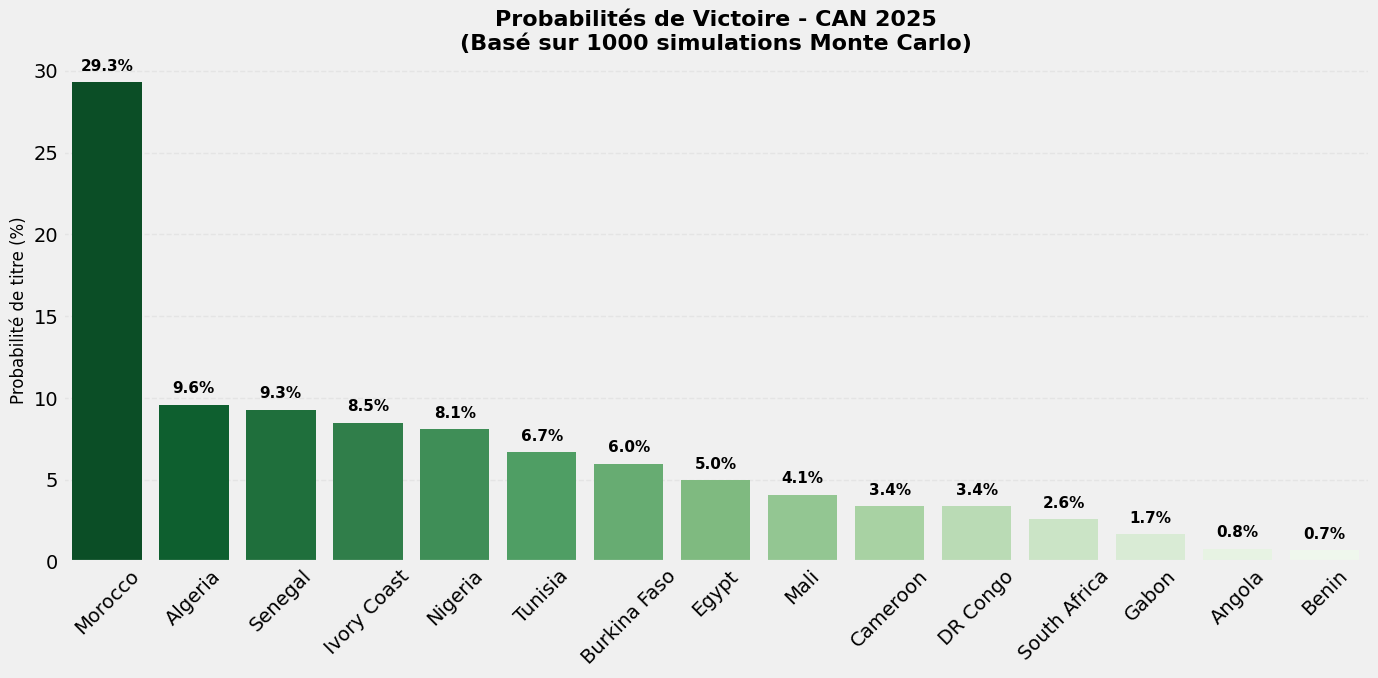

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

data = []
for team, stats in knockout_stats.items():
    win_prob = (stats['Winner'] / NUM_SIMULATIONS) * 100
    if win_prob > 0.5:
        data.append({'Team': team, 'Probability': win_prob})

df_res = pd.DataFrame(data).sort_values('Probability', ascending=False)

plt.figure(figsize=(14, 7))

custom_palette = sns.color_palette("RdYlGn_r", n_colors=len(df_res))
colors = sns.color_palette("Greens_r", len(df_res))

ax = sns.barplot(data=df_res, x='Team', y='Probability', palette=colors)

plt.title(f'Probabilités de Victoire - CAN 2025\n(Basé sur {NUM_SIMULATIONS} simulations Monte Carlo)', fontsize=16, fontweight='bold')
plt.ylabel('Probabilité de titre (%)', fontsize=12)
plt.xlabel('', fontsize=12)
plt.xticks(rotation=45) 
for i, v in enumerate(df_res['Probability']):
    ax.text(i, v + 0.5, f'{v:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=11)

sns.despine()
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()

plt.show()

## Explicabilité : Qu'est-ce qui fait gagner un match ?

Il est crucial de ne pas utiliser le modèle comme une "boîte noire". Ici, nous analysons les **coefficients** de notre RF pour comprendre l'importance de chaque variable.

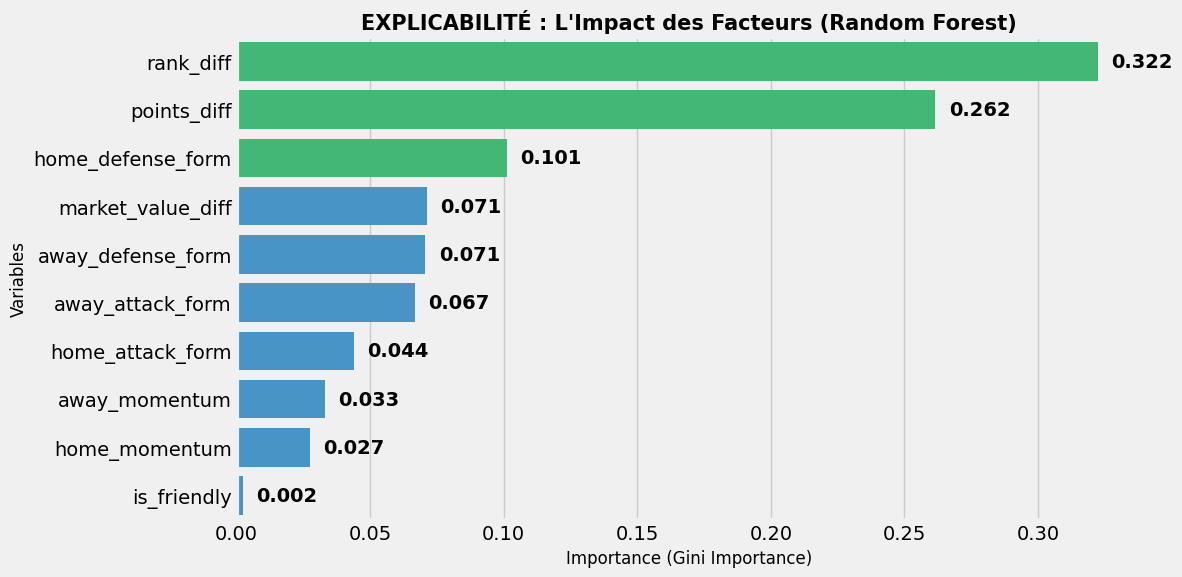


Feature Importance Ranking:
--------------------------------------------------
rank_diff                 : 0.3224 (32.2%)
points_diff               : 0.2616 (26.2%)
home_defense_form         : 0.1012 (10.1%)
market_value_diff         : 0.0711 (7.1%)
away_defense_form         : 0.0707 (7.1%)
away_attack_form          : 0.0668 (6.7%)
home_attack_form          : 0.0438 (4.4%)
away_momentum             : 0.0329 (3.3%)
home_momentum             : 0.0274 (2.7%)
is_friendly               : 0.0023 (0.2%)


In [31]:
features_names = [
    'rank_diff', 'points_diff', 
    'market_value_diff',
    'home_momentum', 'away_momentum',
    'home_attack_form', 'away_attack_form',
    'home_defense_form', 'away_defense_form',
    'is_friendly'
]

# Extract feature importances
importances_home = pd.Series(
    model_home.feature_importances_, 
    index=features_names
).sort_values(ascending=False)

importances_away = pd.Series(
    model_away.feature_importances_, 
    index=features_names
).sort_values(ascending=False)

# Average importances for home and away
avg_importances = ((importances_home + importances_away) / 2).sort_values(ascending=False)

# Visualization
plt.figure(figsize=(12, 6))
colors = ['#2ecc71' if x > 0.1 else '#3498db' for x in avg_importances.values]
ax = sns.barplot(x=avg_importances.values, y=avg_importances.index, palette=colors)

plt.title("EXPLICABILITÉ : L'Impact des Facteurs (Random Forest)", fontsize=15, fontweight='bold')
plt.xlabel("Importance (Gini Importance)", fontsize=12)
plt.ylabel("Variables", fontsize=12)

# Add percentage labels on bars
for i, v in enumerate(avg_importances.values):
    ax.text(v + 0.005, i, f'{v:.3f}', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("\nFeature Importance Ranking:")
print("-" * 50)
for feat, imp in avg_importances.items():
    print(f"{feat:<25} : {imp:.4f} ({imp*100:.1f}%)")



# Analyse Feature Importance - Random Forest

## Top 3 (68.5% de l'impact)

**1. Rank Difference (32.2%)**
- Le classement FIFA est le facteur dominant
- 10 places d'écart ≈ 15% de probabilité de victoire en plus

**2. Points Difference (26.2%)**
- Plus précis que le rang seul
- Capture la dynamique récente (montée/déclin)

**3. Home Defense Form (10.1%)**
- La défense pèse 2x plus que l'attaque
- CAN 2023: Maroc champion avec 1 but encaissé en 7 matchs
- Les tournois africains se gagnent en défense

## Tier 2 (21%)

**Market Value (7.1%)**
- Moins important que prévu
- Explique les upsets (Comores bat Ghana malgré 10x moins de valeur)

**Away Defense (7.1%)** + **Away Attack (6.7%)** + **Home Attack (4.4%)**
- Attaque extérieure > Attaque domicile (paradoxe)
- Les équipes qui jouent bien dehors sont plus complètes

## Tier 3 (6%)

**Momentum (6%)** - Utile pour départager des équipes proches
**Is Friendly (0.2%)** - Négligeable (déjà intégré via le poids 3x)

## Conclusion

**Pour prédire un match:**
1. Classement FIFA (60%)
2. Solidité défensive (20%)
3. Valeur + attaque (15%)
4. Contexte (5%)

## Finding the Dark Horses of the Tournament

Every Africa Cup of Nations delivers a surprise story smaller nation defying the odds to reach the final stages.

In this section, we filter our simulation results to identify these **"Dark Horses"**.
* **The Logic:** We exclude the traditional "Top 10" powerhouses (Morocco, Senegal, Egypt, etc.).
* **The Goal:** Find teams outside this elite group that statistically manage to reach the **Semi-Finals** in our simulations. These are the teams to watch for a potential upset.

In [32]:
top_10_teams = ['Morocco', 'Senegal', 'Nigeria', 'Egypt', 'Ivory Coast', 'Algeria', 'Tunisia', 'Cameroon', 'Mali', 'South Africa']
cinderellas = []
for team, stats in knockout_stats.items():
    if team not in top_10_teams and stats['SF'] > 0:
        prob = (stats['SF'] / NUM_SIMULATIONS) * 100
        cinderellas.append((team, prob))

print("\n LES CENDRILIONS DE LA CAN (Outsiders en Demi-Finale) :")
for team, prob in sorted(cinderellas, key=lambda x: x[1], reverse=True):
    print(f"- {team}: {prob:.1f}% de chances de créer l'exploit")


 LES CENDRILIONS DE LA CAN (Outsiders en Demi-Finale) :
- Burkina Faso: 29.1% de chances de créer l'exploit
- DR Congo: 16.0% de chances de créer l'exploit
- Gabon: 11.8% de chances de créer l'exploit
- Angola: 10.0% de chances de créer l'exploit
- Benin: 8.0% de chances de créer l'exploit
- Zambia: 4.3% de chances de créer l'exploit
- Equatorial Guinea: 4.1% de chances de créer l'exploit
- Uganda: 3.0% de chances de créer l'exploit
- Mozambique: 1.8% de chances de créer l'exploit
- Sudan: 1.6% de chances de créer l'exploit
- Comoros: 1.4% de chances de créer l'exploit
- Zimbabwe: 1.0% de chances de créer l'exploit
- Tanzania: 1.0% de chances de créer l'exploit
- Botswana: 0.2% de chances de créer l'exploit


## Case Study: The "Nightmare" Scenario for Morocco

While Morocco is a favorite, no team is invincible. In this section, we analyze the **risk**.
* We filter all simulations where Morocco was eliminated.
* We identify **which team** knocked them out most frequently.
* **Goal:** Identify the team statistically most dangerous to the hosts.

In [33]:
import collections

morocco_killers = []


for i in range(NUM_SIMULATIONS):
    current_standings = {}
    current_thirds = []
    for grp_name, teams in official_groups.items():
        pts = {t: 0 for t in teams}; gf = {t: 0 for t in teams}; gd = {t: 0 for t in teams}
        for i in range(len(teams)):
            for j in range(i+1, len(teams)):
                s1, s2 = simulate_match_final(teams[i], teams[j])
                if s1 > s2: pts[teams[i]]+=3
                elif s2 > s1: pts[teams[j]]+=3
                else: pts[teams[i]]+=1; pts[teams[j]]+=1
        rank = sorted(teams, key=lambda x: (pts[x]), reverse=True)
        current_standings[grp_name] = {'1': rank[0], '2': rank[1]}
        current_thirds.append({'t': rank[2], 'g': grp_name, 'p': pts[rank[2]]})
    
    # 2. QUALIF 3èmes
    best3 = sorted(current_thirds, key=lambda x: x['p'], reverse=True)[:4]
    qual_code = "".join(sorted([x['g'] for x in best3]))
    mapping = get_opponent_mapping(qual_code)
    def get3(g): 
        for x in best3: 
            if x['g']==g: return x['t']
        return best3[0]['t']

    def play_and_track(t1, t2, stage):
        w, _ = simulate_match_final(t1, t2, is_knockout=True)
        loser = t2 if w == t1 else t1
        # LA TRAQUE EST ICI :
        if loser == 'Morocco':
            morocco_killers.append(w)
        return w

    # Huitièmes
    w1 = play_and_track(current_standings['D']['1'], get3(mapping['1D'][1]), 'R16')
    w2 = play_and_track(current_standings['A']['2'], current_standings['C']['2'], 'R16')
    w3 = play_and_track(current_standings['A']['1'], get3(mapping['1A'][1]), 'R16')
    w4 = play_and_track(current_standings['B']['2'], current_standings['F']['2'], 'R16')
    w5 = play_and_track(current_standings['B']['1'], get3(mapping['1B'][1]), 'R16')
    w6 = play_and_track(current_standings['F']['1'], current_standings['E']['2'], 'R16')
    w7 = play_and_track(current_standings['E']['1'], current_standings['D']['2'], 'R16')
    w8 = play_and_track(current_standings['C']['1'], get3(mapping['1C'][1]), 'R16')

    # Quarts
    q1 = play_and_track(w1, w2, 'QF')
    q2 = play_and_track(w3, w4, 'QF') # Maroc ici
    q3 = play_and_track(w5, w6, 'QF')
    q4 = play_and_track(w7, w8, 'QF')

    # Demis
    d1 = play_and_track(q1, q2, 'SF') # Maroc ici
    d2 = play_and_track(q3, q4, 'SF')

    # Finale
    final_winner = play_and_track(d1, d2, 'Final') 

killer_counts = collections.Counter(morocco_killers)
total_losses = sum(killer_counts.values())

print("\nSCÉNARIO CAUCHEMAR : Qui élimine le Maroc ?")
print(f"(Sur {total_losses} éliminations simulées)")
print("-" * 40)
for team, count in killer_counts.most_common(5):
    percentage = (count / total_losses) * 100
    print(f"🔪 {team:<15} : {percentage:.1f}% des éliminations")

worst_enemy = killer_counts.most_common(1)[0][0]
print("-" * 40)
print(f"CONCLUSION : Si le Maroc ne gagne pas, c'est très probablement à cause de : {worst_enemy.upper()}.")


SCÉNARIO CAUCHEMAR : Qui élimine le Maroc ?
(Sur 706 éliminations simulées)
----------------------------------------
🔪 Tunisia         : 14.0% des éliminations
🔪 Senegal         : 12.5% des éliminations
🔪 Nigeria         : 9.1% des éliminations
🔪 Ivory Coast     : 8.6% des éliminations
🔪 Cameroon        : 8.2% des éliminations
----------------------------------------
CONCLUSION : Si le Maroc ne gagne pas, c'est très probablement à cause de : TUNISIA.


In [34]:
import pickle

# Sauvegarder les modèles
with open('model_home.pkl', 'wb') as f:
    pickle.dump(model_home, f)

with open('model_away.pkl', 'wb') as f:
    pickle.dump(model_away, f)

# Sauvegarder les données des équipes
with open('teams_data.pkl', 'wb') as f:
    pickle.dump(teams_data, f)

with open('groups.pkl', 'wb') as f:
    pickle.dump(official_groups, f)

print("Modèles sauvegardés")

Modèles sauvegardés


# 6. Final Conclusion & Insights 📝

### The Favorites
Based on our simulations, the teams with the highest probability of winning are consistent with high FIFA rankings and strong recent form.

### The Host Factor
Playing at home provides a significant statistical boost. However, as our "Nightmare Analysis" shows, dangerous opponents in the knockout stages pose the biggest threat to the title.

### Future Improvements & Limitations
* **Individual Player Form:** I aimed to include individual performance metrics (last 6 months form) for key African players. However, this required granular historical data for thousands of players, which is currently behind premium paywalls (e.g., Opta, Wyscout).
* **Injury Integration:** Accounting for last-minute injuries to star players would improve short-term accuracy.
* **Expected Goals (xG):** Moving beyond simple goals to "Expected Goals" would provide a better measure of underlying attack strength.

https://www.kaggle.com/code/younessboumlik/ai-predictor-can-2025